In [1]:
import os
# from os.path import expanduser
# home = expanduser("~/")

# import sys
# # sys.path.insert(0, '/global/u2/x/xshuang/gigalens-xh-dev/src')

# # import sys
# conda_env = sys.path[1]
# del sys.path[1]

# import os
# # sys.path.append(f'{os.environ['HOME']}/gigalens_personal/gigalens/src')
# sys.path.append(home+'/gigalens'+'/src')
# sys.path.append(conda_env)
# sys.path.append(home+'/GIGALens-Code/')
# print(sys.path)



# srcdir = os.path.join(home, "gigalens/src/")

In [2]:
import tensorflow_probability.substrates.jax as tfp

from gigalens.jax.inference import ModellingSequence
from gigalens.jax.model import ForwardProbModel, BackwardProbModel
from gigalens.model import PhysicalModel
from gigalens.jax.simulator import LensSimulator
from gigalens.simulator import SimulatorConfig
from gigalens.jax.profiles.light import sersic
from gigalens.jax.profiles.mass import epl, shear

import jax
from jax import random
import numpy as np
import optax
from jax import numpy as jnp
from matplotlib import pyplot as plt
import optax
import corner
import yaml
import pickle
# from helpers import *
import blackjax
import importlib
tfd = tfp.distributions

from mclmc_alt import MCLMC

2026-02-17 14:44:15.907056: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771368256.137780 1825850 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771368256.197464 1825850 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771368256.609307 1825850 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771368256.609324 1825850 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771368256.609327 1825850 computation_placer.cc:177] computation placer alr

In [3]:
#* Define Priors
lens_prior = tfd.JointDistributionSequential(
    [
        tfd.JointDistributionNamed(
            dict(
                theta_E=tfd.LogNormal(jnp.log(1.25), 0.25),
                gamma=tfd.TruncatedNormal(2, 0.25, 1, 3),
                e1=tfd.Normal(0, 0.1),
                e2=tfd.Normal(0, 0.1),
                center_x=tfd.Normal(0, 0.05),
                center_y=tfd.Normal(0, 0.05),
            )
        ),
        tfd.JointDistributionNamed(
            dict(gamma1=tfd.Normal(0, 0.05), gamma2=tfd.Normal(0, 0.05))
        ),
    ]
)
lens_light_prior = tfd.JointDistributionSequential(
    [
        tfd.JointDistributionNamed(
            dict(
                R_sersic=tfd.LogNormal(jnp.log(1.0), 0.15),
                n_sersic=tfd.Uniform(2, 6),
                e1=tfd.TruncatedNormal(0, 0.1, -0.3, 0.3),
                e2=tfd.TruncatedNormal(0, 0.1, -0.3, 0.3),
                center_x=tfd.Normal(0, 0.05),
                center_y=tfd.Normal(0, 0.05),
                Ie=tfd.LogNormal(jnp.log(500.0), 0.3),
            )
        )
    ]
)

source_light_prior = tfd.JointDistributionSequential(
    [
        tfd.JointDistributionNamed(
            dict(
                R_sersic=tfd.LogNormal(jnp.log(0.25), 0.15),
                n_sersic=tfd.Uniform(0.5, 4),
                e1=tfd.TruncatedNormal(0, 0.15, -0.5, 0.5),
                e2=tfd.TruncatedNormal(0, 0.15, -0.5, 0.5),
                center_x=tfd.Normal(0, 0.25),
                center_y=tfd.Normal(0, 0.25),
                Ie=tfd.LogNormal(jnp.log(150.0), 0.5),
            )
        )
    ]
)

prior = tfd.JointDistributionSequential(
    [lens_prior, lens_light_prior, source_light_prior]
)

In [4]:
from os.path import expanduser
home = expanduser("~/")
gigal_dir = os.path.join(home,'gigalens/src/gigalens/')
kernel = np.load(gigal_dir + '/assets/psf.npy').astype(np.float32)
sim_config = SimulatorConfig(delta_pix=0.065, num_pix=60, supersample=2, kernel=kernel)
phys_model = PhysicalModel([epl.EPL(50), shear.Shear()], [sersic.SersicEllipse(use_lstsq=False)], [sersic.SersicEllipse(use_lstsq=False)])
lens_sim = LensSimulator(phys_model, sim_config, bs=1)
observed_img = np.load(gigal_dir + '/assets/demo.npy')
prob_model = ForwardProbModel(prior, observed_img, background_rms=0.2, exp_time=100)
model_seq = ModellingSequence(phys_model, prob_model, sim_config)

In [5]:
opt = optax.adabelief(1e-2, b1=0.95, b2=0.99)
best, chisq, lp = model_seq.MAP(opt, seed=0)

MAP took 18.6s
Final Chi-squared: 0.98418790102005


2026-02-17 14:45:41.886477: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.


SVI took 57.3s
Min -ELBO: -73.647


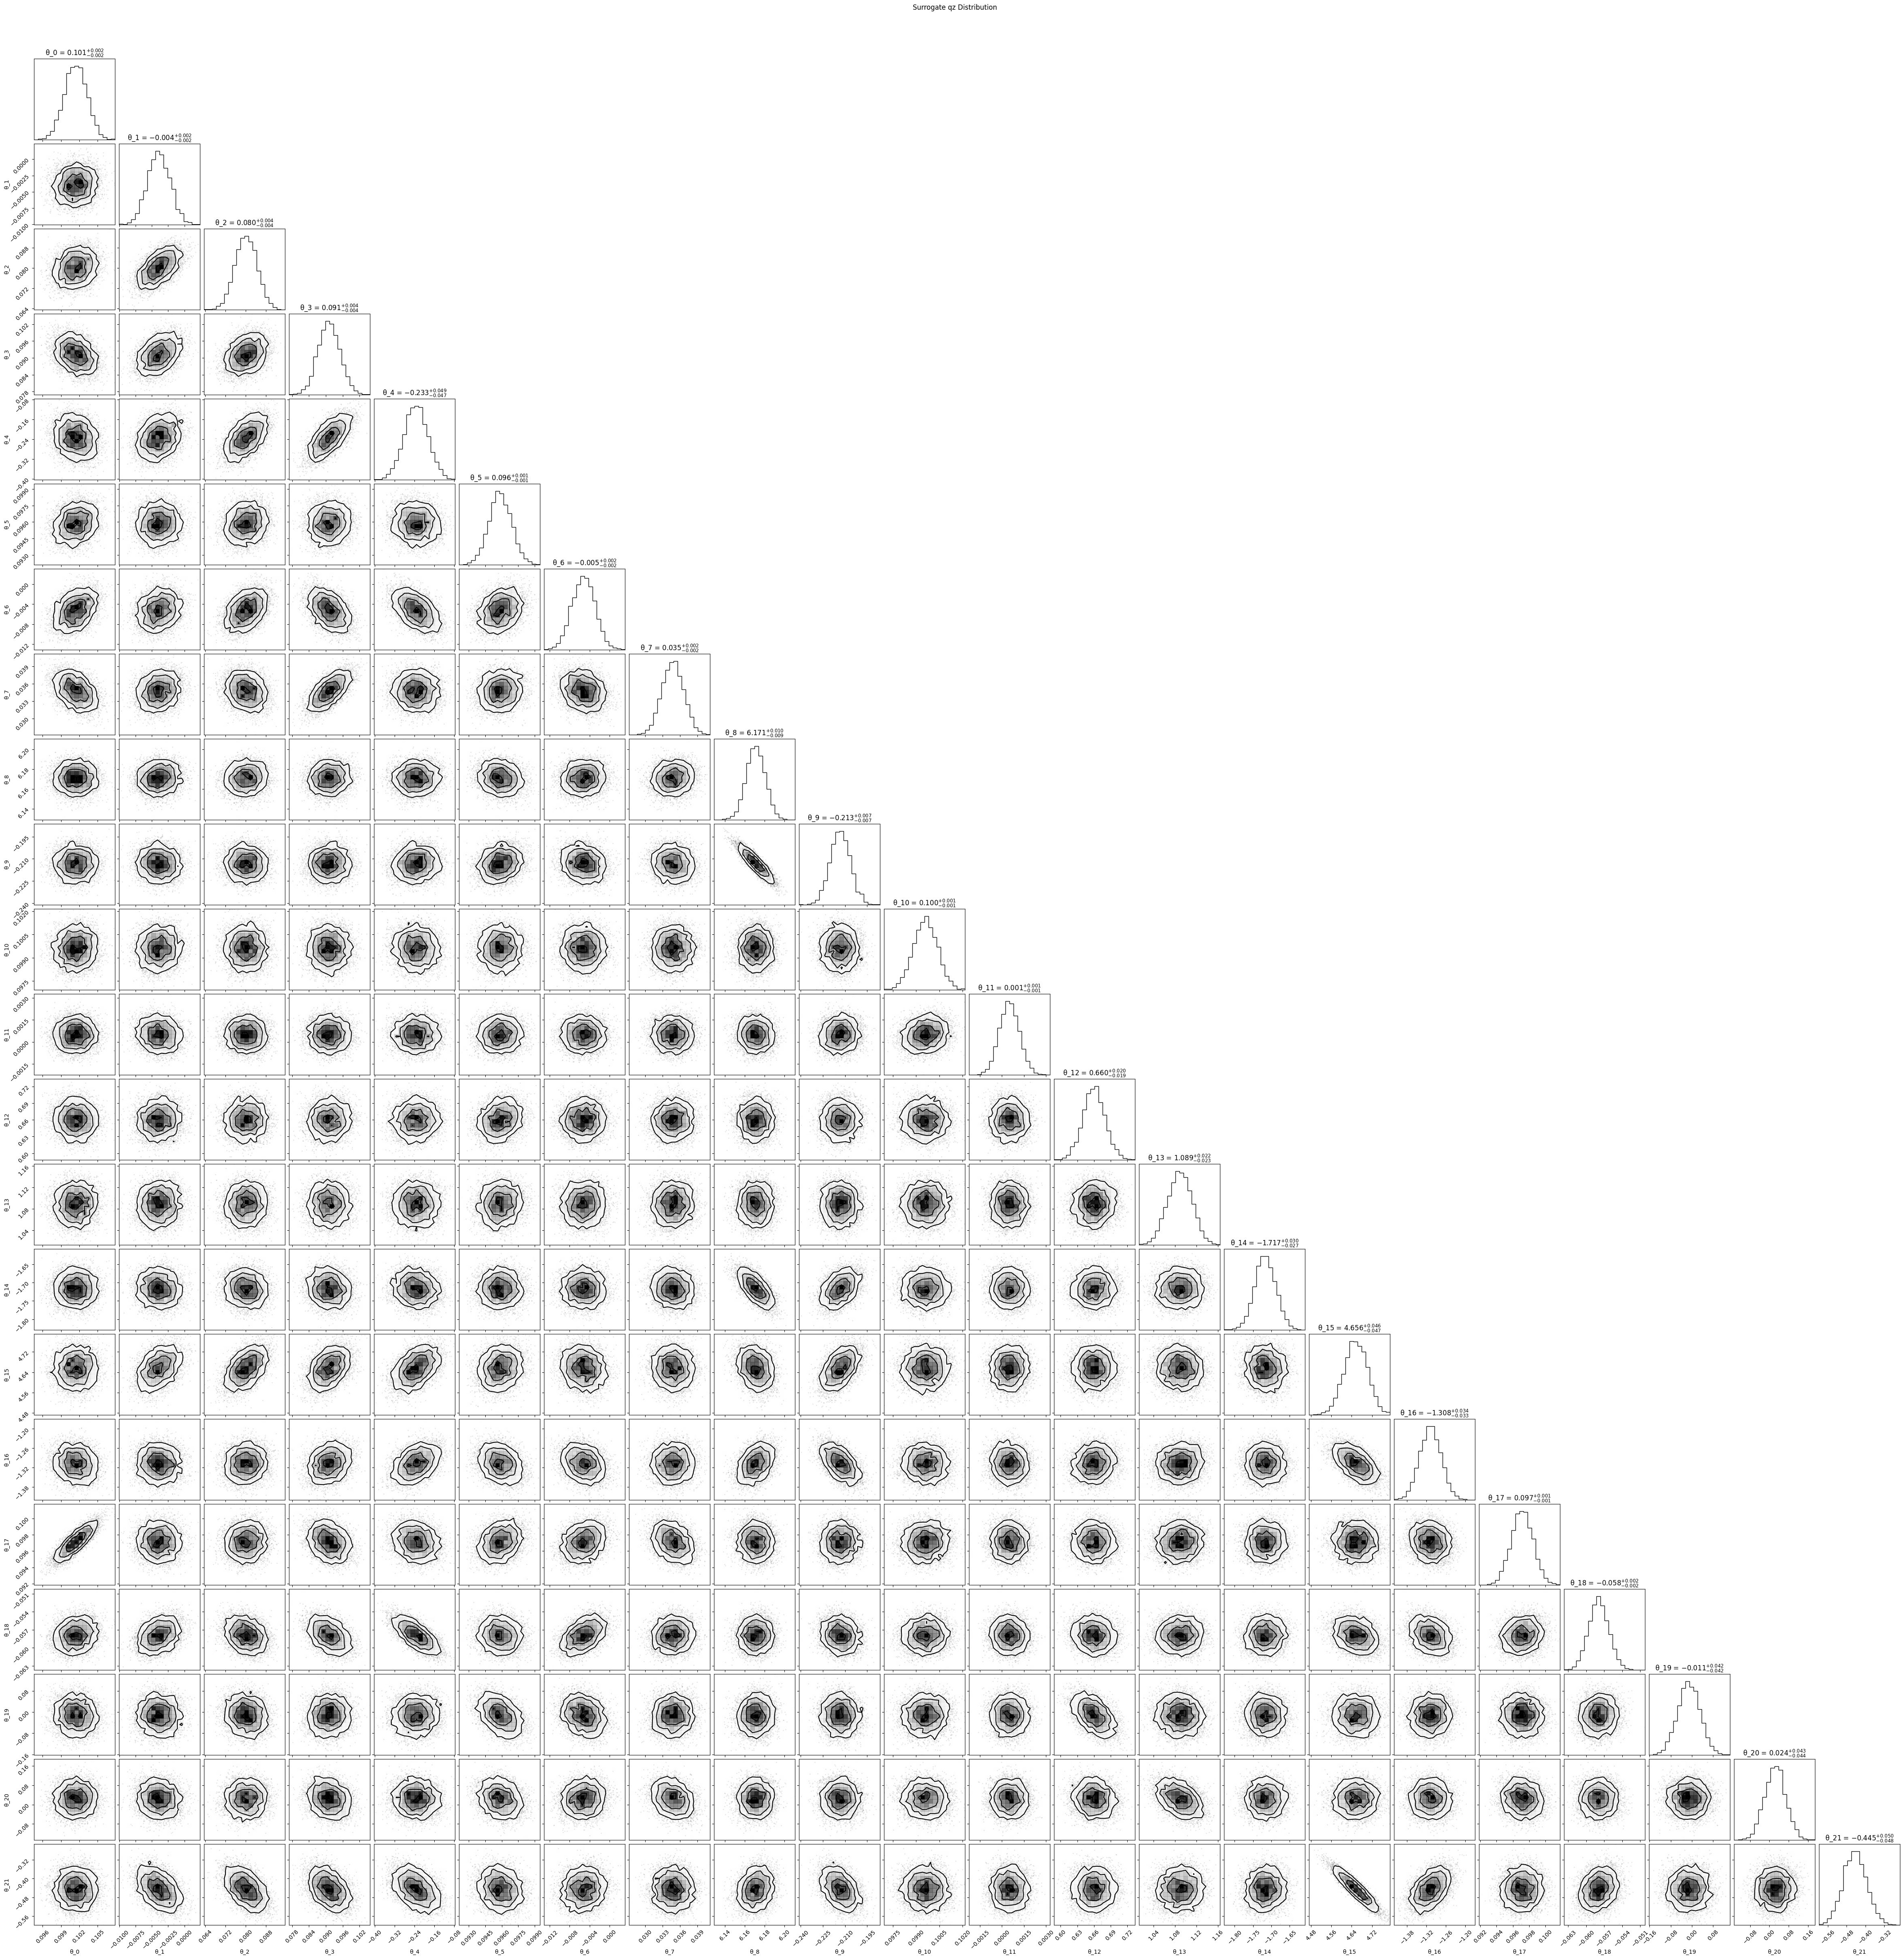

In [6]:
opt = optax.adabelief(1e-4, b1=0.95, b2=0.99)
qz, loss_hist = model_seq.SVI(best, opt, n_vi=1000, num_steps=1500)

import corner
import jax

qz_samples = np.array(qz.sample((5000,), seed=jax.random.key(42)))
fig = corner.corner(
    qz_samples,
    labels=[f'θ_{i}' for i in range(qz_samples.shape[1])],
    show_titles=True,
    title_fmt='.3f',
)

plt.suptitle('Surrogate qz Distribution', y=1.02)
plt.savefig('qz_corner.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
hmc_samples = model_seq.HMC(qz, num_burnin_steps=250, num_results=750, n_hmc=16)

Sampling took 21.8s


In [8]:
# Note that right now, MCLMC only runs on 1 GPU, so times are not comparable
#mclmc_samples = MCLMC(model_seq, qz, n_hmc=16, num_burnin_steps=1000, num_results=2000)

In [ ]:
import nuts
from importlib import reload
reload(nuts)

nuts_samples = nuts.NUTS(
    model_seq=model_seq,
    qz=qz,
    num_warmup_steps=100,
    num_results=10,
    progress_bar=True,
    seed=42,
    mass_matrix_adapt=True
)
print(f"Samples shape: {nuts_samples.shape}")

2026-02-17 14:47:36.704709: E external/xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng2{k2=2,k3=0} for conv %cudnn-conv-bw-input = (f32[16,1,120,120]{3,2,1,0}, u8[0]{0}) custom-call(%bitcast.10, %param.24), window={size=25x25 pad=12_12x12_12}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardInput", metadata={op_name="jit(log_prob)/jit(main)/jit(simulate)/conv_general_dilated" source_file="/global/u1/c/chaseg/desi-238/nuts.py" source_line=87}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2026-02-17 14:47:37.195883: E external/xla/xla/service/slow_operation_alarm.cc:140] The operation took 1.491308297s
Trying algorithm eng2{k2=2,k3=0} for conv %cudnn-conv-bw-input = (f32[16,1,120,120]{3,2,1,0}, u8[0]{0}) custom-call(%bitcast.10, %para

Starting warmup (with mass matrix adaptation)...


In [ ]:
import corner

# Flatten chains: (num_results * n_chains, dim)
nuts_flat = np.array(nuts_samples).reshape(-1, nuts_samples.shape[-1])

fig = corner.corner(
    nuts_flat,
    labels=[f'θ_{i}' for i in range(nuts_flat.shape[1])],
    show_titles=True,
    title_fmt='.3f',
    smooth=1.0,
)
plt.savefig('nuts_corner.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
ESS_hmc = blackjax.diagnostics.effective_sample_size(hmc_samples, chain_axis=1, sample_axis=0)
ESS_nuts = blackjax.diagnostics.effective_sample_size(nuts_samples, chain_axis=1, sample_axis=0)

print("HMC: Mean ESS | Min ESS")
print(np.mean(ESS_hmc), " | ", jnp.min(ESS_hmc))
print("NUTS: Mean ESS | Min ESS")
print(np.mean(ESS_nuts), " | ", jnp.min(ESS_nuts))
Rhat_hmc = blackjax.diagnostics.potential_scale_reduction(hmc_samples, chain_axis=1, sample_axis=0)
Rhat_nuts = blackjax.diagnostics.potential_scale_reduction(nuts_samples, chain_axis=1, sample_axis=0)

print("HMC: Mean Rhat | Max Rhat")
print(np.mean(Rhat_hmc), " | ", jnp.max(Rhat_hmc))
print("NUTS: Mean Rhat | Max Rhat")
print(np.mean(Rhat_nuts), " | ", jnp.max(Rhat_nuts))

print(f"\nPer parameter R-hat:")
for i, rhat in enumerate(Rhat_nuts):
    status = "✓" if rhat < 1.01 else "✗"
    print(f"  θ_{i}: {rhat:.4f} {status}")